## РК №1 ТМО
### Марков И.С. ИУ5Ц-81Б
#### Вариант №27
#### Задача №4: Технологии разведочного анализа и обработки данных
#### Датасет: https://www.kaggle.com/datasets/johnsmith88/heart-disease-dataset

In [51]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Загрузка данных
df = pd.read_csv('archive/heart.csv')

# Первичный осмотр данных
print("Первые 5 строк данных:")
print(df.head())
print("\nИнформация о данных:")
print(df.info())


Первые 5 строк данных:
   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   52    1   0       125   212    0        1      168      0      1.0      2   
1   53    1   0       140   203    1        0      155      1      3.1      0   
2   70    1   0       145   174    0        1      125      1      2.6      0   
3   61    1   0       148   203    0        1      161      0      0.0      2   
4   62    0   0       138   294    1        1      106      0      1.9      1   

   ca  thal  target  
0   2     3       0  
1   0     3       0  
2   0     3       0  
3   1     3       0  
4   3     2       0  

Информация о данных:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int

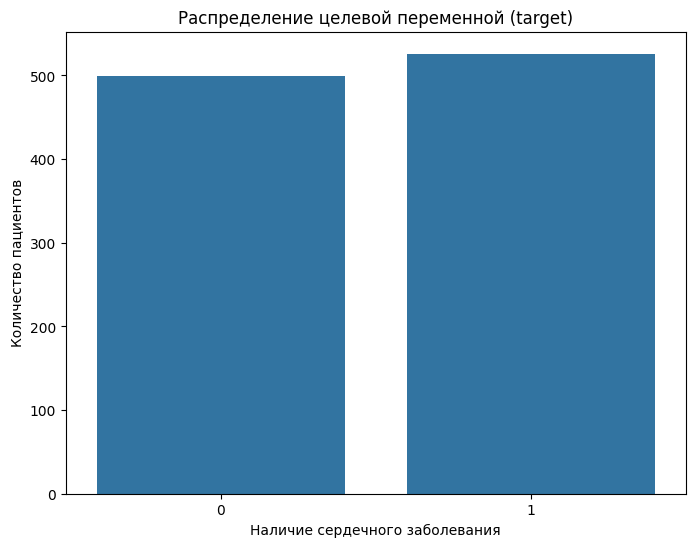


Распределение целевой переменной:
target
1    526
0    499
Name: count, dtype: int64

Процент пациентов с заболеванием сердца: 51.3%
Процент пациентов без заболевания сердца: 48.7%


In [52]:
# Распределение целевой переменной
plt.figure(figsize=(8, 6))
sns.countplot(x='target', data=df)
plt.title('Распределение целевой переменной (target)')
plt.xlabel('Наличие сердечного заболевания')
plt.ylabel('Количество пациентов')
plt.show()

# Статистика по целевой переменной
target_counts = df['target'].value_counts()
print("\nРаспределение целевой переменной:")
print(target_counts)
print(f"\nПроцент пациентов с заболеванием сердца: {target_counts[1]/len(df)*100:.1f}%")
print(f"Процент пациентов без заболевания сердца: {target_counts[0]/len(df)*100:.1f}%")

Выводы:

- 51.3% пациентов имеют сердечное заболевание (target=1)

- 48.7% пациентов не имеют сердечного заболевания (target=0)

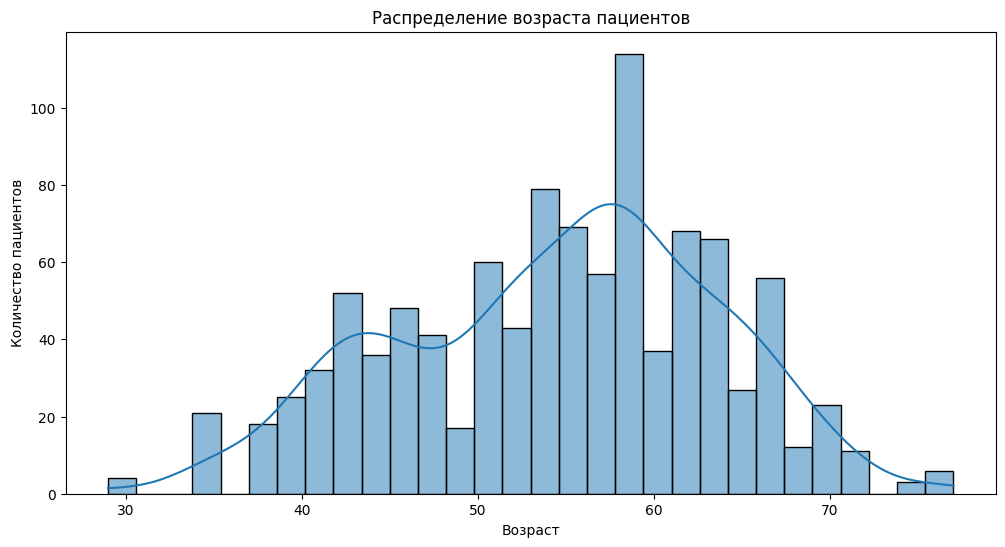


Описательная статистика по возрасту:
count    1025.000000
mean       54.434146
std         9.072290
min        29.000000
25%        48.000000
50%        56.000000
75%        61.000000
max        77.000000
Name: age, dtype: float64


In [53]:
# Распределение возраста
plt.figure(figsize=(12, 6))
sns.histplot(df['age'], bins=30, kde=True)
plt.title('Распределение возраста пациентов')
plt.xlabel('Возраст')
plt.ylabel('Количество пациентов')
plt.show()

# Описательная статистика по возрасту
print("\nОписательная статистика по возрасту:")
print(df['age'].describe())

Возраст пациентов варьируется от 29 до 77 лет

- Средний возраст пациентов - около 54 лет

- Медианное значение возраста - 56 лет

- Распределение возраста имеет небольшой сдвиг в сторону более молодых пациентов

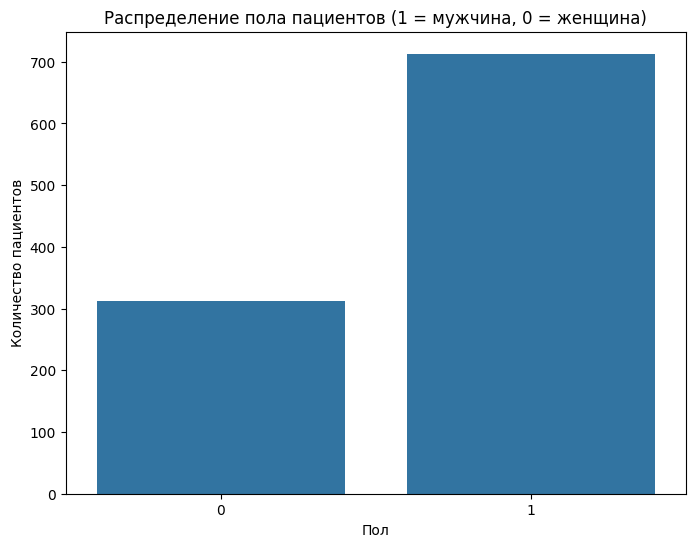


Распределение по полу:
sex
1    713
0    312
Name: count, dtype: int64

Процент мужчин: 69.6%
Процент женщин: 30.4%


In [54]:
# Распределение пола
plt.figure(figsize=(8, 6))
sns.countplot(x='sex', data=df)
plt.title('Распределение пола пациентов (1 = мужчина, 0 = женщина)')
plt.xlabel('Пол')
plt.ylabel('Количество пациентов')
plt.show()

# Статистика по полу
sex_counts = df['sex'].value_counts()
print("\nРаспределение по полу:")
print(sex_counts)
print(f"\nПроцент мужчин: {sex_counts[1]/len(df)*100:.1f}%")
print(f"Процент женщин: {sex_counts[0]/len(df)*100:.1f}%")

Выводы:

- В наборе данных преобладают мужчины (69.6%)

- Женщины составляют 30.4% от общего числа пациентов

- Такое распределение может повлиять на результаты анализа, так как мужчины и женщины могут иметь разные факторы риска

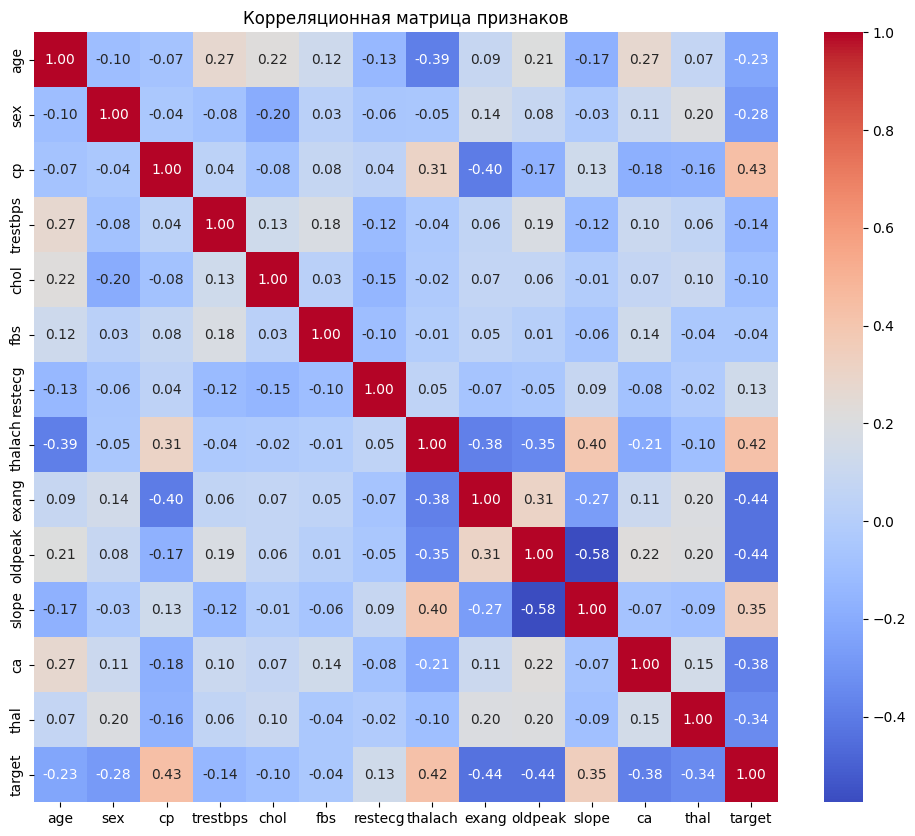


Корреляция признаков с целевой переменной:
target      1.000000
cp          0.434854
thalach     0.422895
slope       0.345512
restecg     0.134468
fbs        -0.041164
chol       -0.099966
trestbps   -0.138772
age        -0.229324
sex        -0.279501
thal       -0.337838
ca         -0.382085
exang      -0.438029
oldpeak    -0.438441
Name: target, dtype: float64


In [55]:
# Корреляционная матрица
plt.figure(figsize=(12, 10))
corr_matrix = df.corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Корреляционная матрица признаков')
plt.show()

# Наиболее коррелирующие с целевой переменной признаки
print("\nКорреляция признаков с целевой переменной:")
print(corr_matrix['target'].sort_values(ascending=False))

Наибольшую положительную корреляцию с целевой переменной имеют:

- cp (тип боли в груди): 0.43

- thalach (максимальная достигнутая ЧСС): 0.42

- slope (наклон сегмента ST при пиковой нагрузке): 0.35

Наибольшую отрицательную корреляцию с целевой переменной имеют:

- exang (стенокардия, вызванная физической нагрузкой): -0.44

- oldpeak (депрессия ST, вызванная физической нагрузкой): -0.43

- ca (количество основных сосудов): -0.39

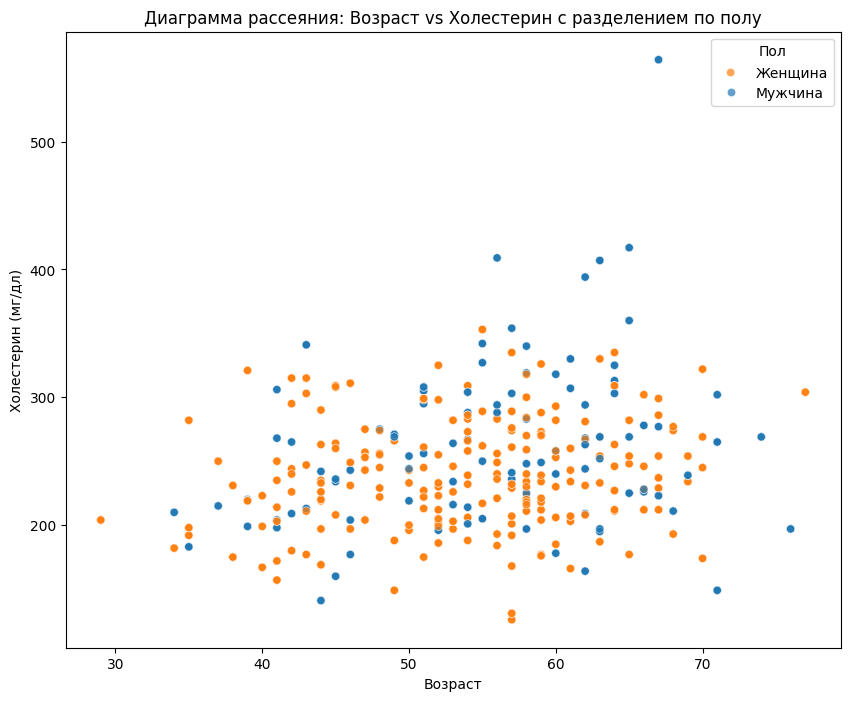

In [56]:
# Диаграмма рассеяния для возраста и холестерина с разделением по полу
plt.figure(figsize=(10, 8))
sns.scatterplot(x='age', y='chol', hue='sex', data=df, alpha=0.7)
plt.title('Диаграмма рассеяния: Возраст vs Холестерин с разделением по полу')
plt.xlabel('Возраст')
plt.ylabel('Холестерин (мг/дл)')
plt.legend(title='Пол', labels=['Женщина', 'Мужчина'])
plt.show()

- Наблюдается слабая положительная тенденция: с возрастом уровень холестерина имеет тенденцию к увеличению

- Есть несколько выбросов с очень высоким уровнем холестерина (>400 мг/дл)

- Распределение холестерина у мужчин и женщин визуально не сильно отличается

- Большинство значений холестерина сосредоточены в диапазоне 200-300 мг/дл

C:\Users\redmi\AppData\Local\Temp\ipykernel_13888\3166104228.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0, 0].set_xticklabels(['Нет', 'Да'])
C:\Users\redmi\AppData\Local\Temp\ipykernel_13888\3166104228.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0, 1].set_xticklabels(['Нет', 'Да'])
C:\Users\redmi\AppData\Local\Temp\ipykernel_13888\3166104228.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1, 0].set_xticklabels(['Нет', 'Да'])
C:\Users\redmi\AppData\Local\Temp\ipykernel_13888\3166104228.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1, 1].set_xticklabels(['Нет', 'Да'])


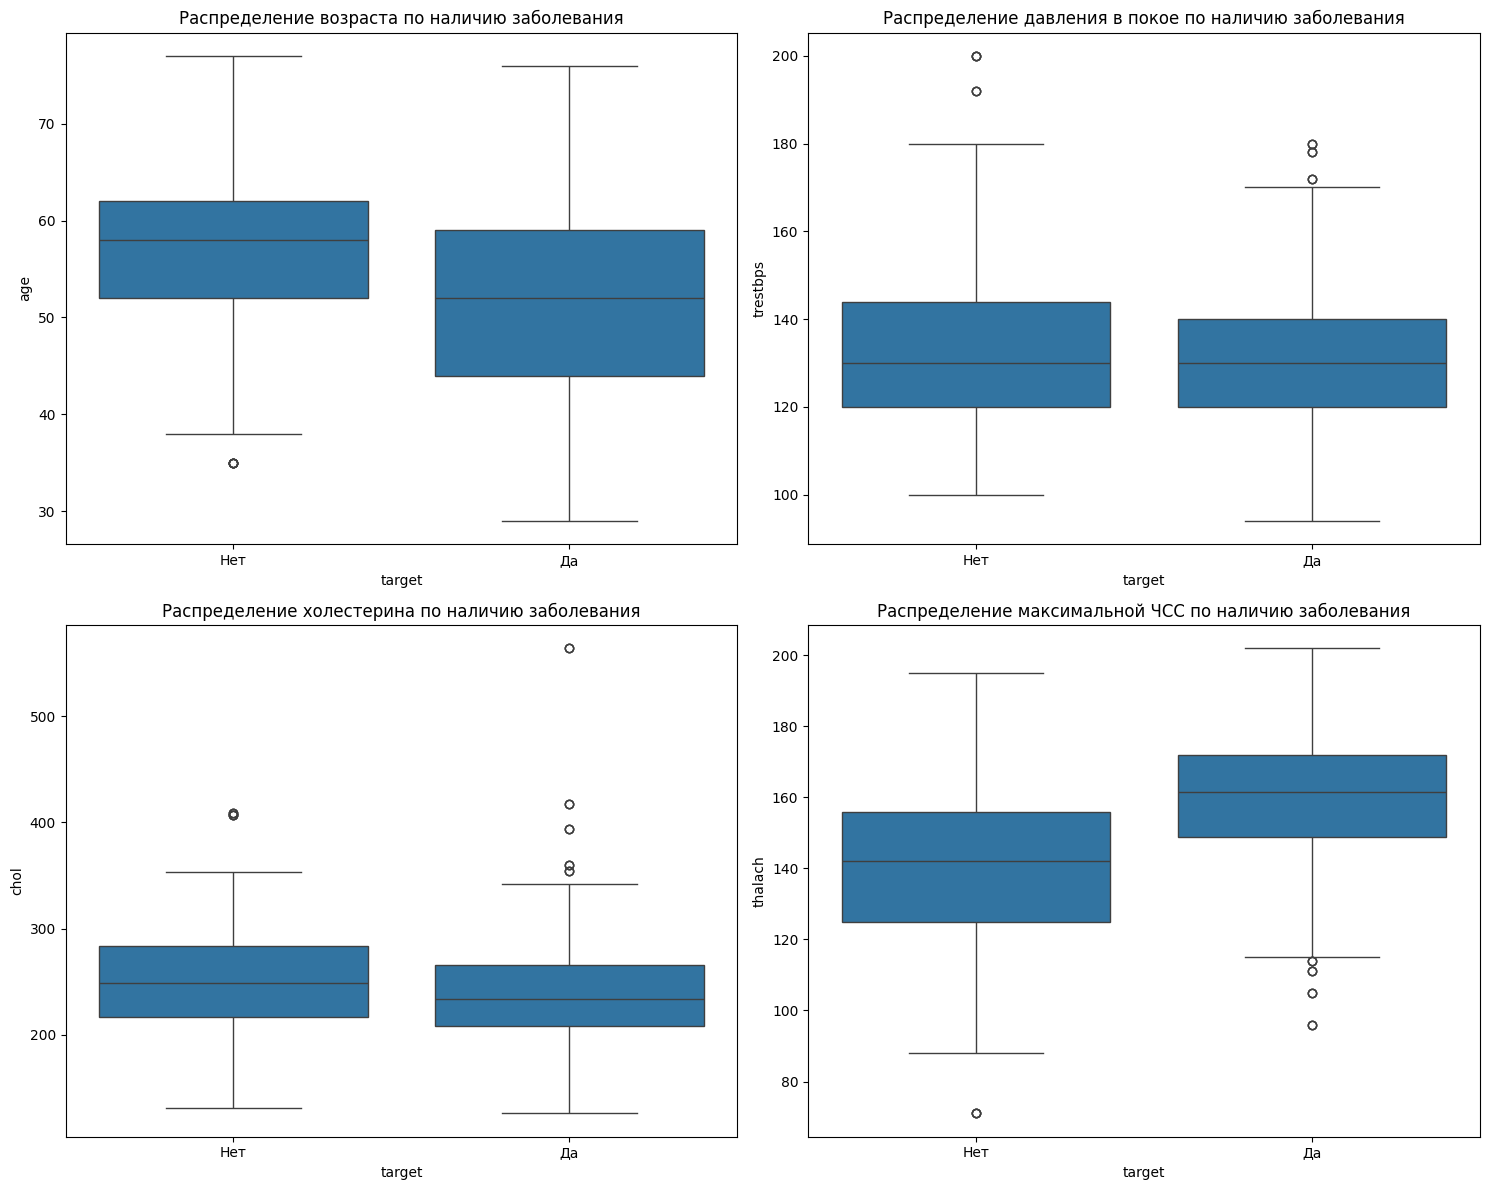

In [57]:
# Сравнение распределений ключевых показателей для пациентов с заболеванием и без
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

sns.boxplot(x='target', y='age', data=df, ax=axes[0, 0])
axes[0, 0].set_title('Распределение возраста по наличию заболевания')
axes[0, 0].set_xticklabels(['Нет', 'Да'])

sns.boxplot(x='target', y='trestbps', data=df, ax=axes[0, 1])
axes[0, 1].set_title('Распределение давления в покое по наличию заболевания')
axes[0, 1].set_xticklabels(['Нет', 'Да'])

sns.boxplot(x='target', y='chol', data=df, ax=axes[1, 0])
axes[1, 0].set_title('Распределение холестерина по наличию заболевания')
axes[1, 0].set_xticklabels(['Нет', 'Да'])

sns.boxplot(x='target', y='thalach', data=df, ax=axes[1, 1])
axes[1, 1].set_title('Распределение максимальной ЧСС по наличию заболевания')
axes[1, 1].set_xticklabels(['Нет', 'Да'])

plt.tight_layout()
plt.show()

Выводы:

- Пациенты с заболеваниями сердца в среднем немного старше

- Медианный возраст для больных - около 56 лет, для здоровых - около 52 лет

- У пациентов с заболеваниями сердца давление в покое в среднем немного выше

- Медианное значение для больных - около 130 мм рт.ст., для здоровых - около 125 мм рт.ст.

- Разница в распределении холестерина между группами незначительна

- Обе группы имеют схожие медианные значения около 240-250 мг/дл

- Пациенты с заболеваниями сердца имеют более высокую максимальную ЧСС

- Медианное значение для больных - около 160 уд/мин, для здоровых - около 140 уд/мин